# **EDA Notebook Product Cost History**



---
## 0. Setup Environment

In [1]:
# DO NOT MODIFY THE CODE IN THIS CELL
!pip install -q utstd

from utstd.folders import *
from utstd.ipyrenders import *

at = AtFolder(
    course_code=36106,
    assignment="AT3",
)
at.run()

import warnings
warnings.simplefilter(action='ignore')


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip



You can now save your data files in: /Users/shanusharma/Desktop/Python/MDSI/ML/AT3/drive-download-20260516T100846Z-3-001/36106/assignment/AT3/data


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
utstd 0.1.8 requires scikit-learn~=1.5.1, but you have scikit-learn 1.6.1 which is incompatible.

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
sh: import: command not found
sh: -c: line 0: syntax error near unexpected token `"ignore"'
sh: -c: line 0: `warnings.filterwarnings("ignore")'


---
## Student Information

In [2]:
group_name = "20"
student_name = "Shanu Sharma"
student_id = "25979360"

In [3]:
# Do not modify this code
print_tile(size="h1", key='group_name', value=group_name)

In [4]:
# Do not modify this code
print_tile(size="h1", key='student_name', value=student_name)

In [5]:
# Do not modify this code
print_tile(size="h1", key='student_id', value=student_id)

---
## 0. Python Packages

### 0.a Install Additional Packages

> If you are using additional packages, you need to install them here using the command: `! pip install <package_name>`

In [6]:
# No additional packages required for this EDA notebook.

### 0.b Import Packages

In [7]:
# Import packages used for data inspection and plotting.
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

---
## B. Data Understanding

In [8]:
# Do not modify this code
try:
  df = pd.read_csv(at.folder_path / "product_cost_history.csv")
except Exception as e:
  print(e)

### B.1 Explore Dataset

In [9]:
# Preview records and inspect the structure of the product cost history table.
display(df.head())

print(f"Rows and columns: {df.shape}")
print(f"Duplicate rows: {df.duplicated().sum()}")

print("Missing values:")
display(df.isna().sum())

print("Unique values:")
display(df.nunique())

print("Standard cost summary:")
display(df["standard_cost"].describe().round(2))

,product_id,start_date,end_date,standard_cost
0,05385566-38df-4855-94a8-786cae6ffe49,2011-05-31 00:00:00,2012-05-29 00:00:00,12.0278
1,05385566-38df-4855-94a8-786cae6ffe49,2012-05-30 00:00:00,2013-05-29 00:00:00,13.8782
2,05385566-38df-4855-94a8-786cae6ffe49,2013-05-30 00:00:00,NaN,13.0863
3,f33d8a41-b92f-4f2a-8f75-76ea2f25722b,2011-05-31 00:00:00,2012-05-29 00:00:00,12.0278
4,f33d8a41-b92f-4f2a-8f75-76ea2f25722b,2012-05-30 00:00:00,2013-05-29 00:00:00,13.8782


Rows and columns: (395, 4)
Duplicate rows: 0
Missing values:


product_id         0
start_date         0
end_date         195
standard_cost      0
dtype: int64

Unique values:


product_id       293
start_date         3
end_date           2
standard_cost    134
dtype: int64

Standard cost summary:


count     395.00
mean      434.27
std       497.38
min         0.86
25%        37.12
50%       204.63
75%       660.91
max      2171.29
Name: standard_cost, dtype: float64

In [10]:
# Create a working copy with parsed dates and a current-cost flag.
cost_eda = df.copy()
cost_eda["start_date"] = pd.to_datetime(cost_eda["start_date"])
cost_eda["end_date"] = pd.to_datetime(cost_eda["end_date"])
cost_eda["is_current_cost"] = cost_eda["end_date"].isna()

print("Current versus historical cost records:")
display(cost_eda["is_current_cost"].value_counts())

print("Start date distribution:")
display(cost_eda["start_date"].value_counts().sort_index())

print("End date distribution:")
display(cost_eda["end_date"].value_counts(dropna=False).sort_index())

Current versus historical cost records:


is_current_cost
False    200
True     195
Name: count, dtype: int64

Start date distribution:


start_date
2011-05-31     72
2012-05-30    128
2013-05-30    195
Name: count, dtype: int64

End date distribution:


end_date
2012-05-29     72
2013-05-29    128
NaT           195
Name: count, dtype: int64

In [11]:
dataset_insights = """
The product_cost_history dataset contains 395 rows and 4 columns: product_id, start_date, end_date, and standard_cost. Each row represents a cost value for a product during a specific time period. For the clustering analysis, this dataset adds the cost side of product behaviour.

The dataset has no missing product_id, start_date, or standard_cost values, and there are no duplicate rows. end_date has 195 missing values, but these should not be treated as unusable missing data. In a history table, a missing end_date indicates the current active cost record — this is the standard design pattern where the active row has no end date set.

For product-level clustering, this dataset is useful because products should not be grouped only by promotion exposure or sales behaviour. Cost level and cost stability can help identify high-cost products, low-cost products, products with changing cost structures, and products where discounting may create margin pressure.
"""

In [12]:
# Do not modify this code
print_tile(size="h3", key='dataset_insights', value=dataset_insights)

### B.2 Explore Feature of Interest `product_id`

In [13]:
# Count how many cost records exist for each product.
product_cost_counts = (
    cost_eda.groupby("product_id")
    .size()
    .reset_index(name="num_cost_records")
    .sort_values("num_cost_records", ascending=False)
)

display(product_cost_counts.head(10))
display(product_cost_counts["num_cost_records"].describe().round(2))
display(product_cost_counts["num_cost_records"].value_counts().sort_index())

,product_id,num_cost_records
241,cd05d9c2-960f-40b2-b3e3-73774c934af6,3
278,f33d8a41-b92f-4f2a-8f75-76ea2f25722b,3
254,d8f138f9-478a-4494-9eff-60324ce60d13,3
39,1e9130a5-1d77-4ea3-80f6-875f26fcb05a,3
191,9da9449d-397b-4beb-8a8d-95b12a76ccaa,3
37,1c63af8a-5b82-4576-b71b-818d1923ae62,3
56,2f498249-a692-48f7-93d3-af567d3c36d6,3
192,9e4e275e-baa1-44e2-827e-ec3fead348fa,3
59,33383d99-db78-414e-a552-f1c3a3937aee,3
61,34ad3302-abb1-4d4d-9f75-b1c0c5919313,3


count    293.00
mean       1.35
std        0.63
min        1.00
25%        1.00
50%        1.00
75%        2.00
max        3.00
Name: num_cost_records, dtype: float64

num_cost_records
1    216
2     52
3     25
Name: count, dtype: int64

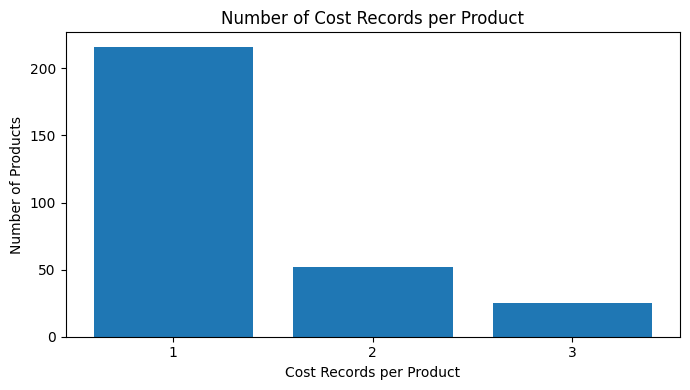

In [14]:
# Plot the number of cost records per product.
record_counts = product_cost_counts["num_cost_records"].value_counts().sort_index()

plt.figure(figsize=(7, 4))
plt.bar(record_counts.index.astype(str), record_counts.values)
plt.title("Number of Cost Records per Product")
plt.xlabel("Cost Records per Product")
plt.ylabel("Number of Products")
plt.tight_layout()
plt.show()

In [15]:
feature_1_insights = """
product_id identifies the products that have cost history records. The dataset contains 293 unique products. Most products have only one cost record, while 52 products have two records and 25 products have three records.

For the retailer, this means most products have stable or single-record cost information, but a smaller group of products has cost changes over time. This distinction is useful for margin-risk clustering because products with changing costs may require closer pricing, promotion, and margin review.

For final clustering, product_id should be used as the aggregation key, not as a modelling feature. The cost history can be converted into product-level features such as num_cost_records, latest_standard_cost, min_standard_cost, max_standard_cost, and cost_range.
"""

In [16]:
# Do not modify this code
print_tile(size="h3", key='feature_1_insights', value=feature_1_insights)

### B.3 Explore Feature of Interest `standard_cost`

In [17]:
# Analyse the distribution of standard_cost across all history records.
display(cost_eda["standard_cost"].describe().round(2))

display(cost_eda[[
    "product_id",
    "start_date",
    "end_date",
    "standard_cost",
    "is_current_cost",
]].sort_values("standard_cost", ascending=False).head(10))

count     395.00
mean      434.27
std       497.38
min         0.86
25%        37.12
50%       204.63
75%       660.91
max      2171.29
Name: standard_cost, dtype: float64

,product_id,start_date,end_date,standard_cost,is_current_cost
102,01225971-c68c-4650-8d3c-f498ece3c5da,2011-05-31,2012-05-29,2171.2942,False
101,378b5732-eba9-46e4-a6c1-4040717835d5,2011-05-31,2012-05-29,2171.2942,False
100,e8c12ae4-8042-4b77-8bd7-023d46440e33,2011-05-31,2012-05-29,2171.2942,False
99,e909a64f-f56c-4f3c-b802-f539d52f8f21,2011-05-31,2012-05-29,2171.2942,False
98,41b7b226-20ea-488a-b519-b4ca65d4a64e,2011-05-31,2012-05-29,2171.2942,False
134,6cc3d977-da73-4856-b1ca-8a2f0b57b60b,2011-05-31,2012-05-29,1912.1544,False
133,a8fcee30-f73d-42fb-a1bb-95d5e9e66a86,2011-05-31,2012-05-29,1912.1544,False
135,5b78ca64-7982-49f2-8ec0-4e6bbfd5450e,2011-05-31,2012-05-29,1912.1544,False
132,a16ed5b0-74c7-4812-adea-04b4abfd72c7,2011-05-31,2012-05-29,1912.1544,False
138,852af53a-5738-432c-90c9-41e230990102,2011-05-31,2012-05-29,1898.0944,False


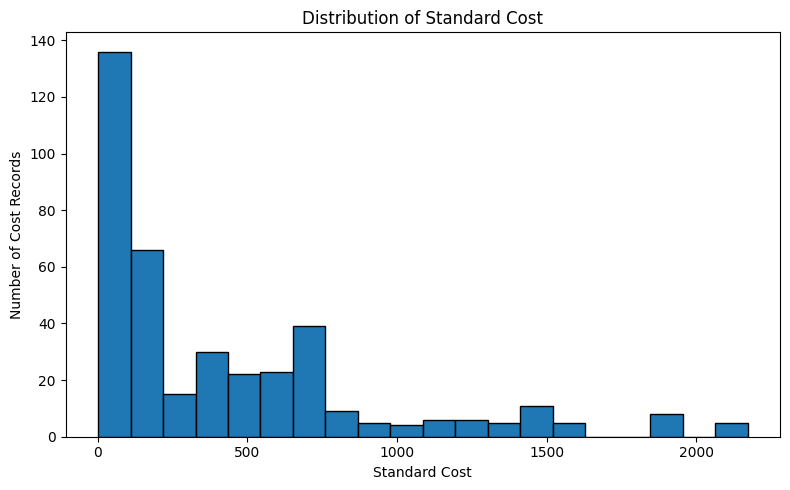

In [18]:
# Plot the standard cost distribution.
plt.figure(figsize=(8, 5))
plt.hist(cost_eda["standard_cost"], bins=20, edgecolor="black")
plt.title("Distribution of Standard Cost")
plt.xlabel("Standard Cost")
plt.ylabel("Number of Cost Records")
plt.tight_layout()
plt.show()

In [19]:
feature_2_insights = """
standard_cost measures the cost of a product to the business during a given time period. Across all cost history records, standard_cost ranges from about 0.86 to 2171.29, with a mean of about 434.27 and a median of about 204.63. The mean is much higher than the median, which shows that the cost distribution is right-skewed and includes some very high-cost products.

For the retailer, cost level is important because discounts and promotions have different business risk depending on product cost. A high-cost product with heavy discount exposure may create margin pressure, while a low-cost product may be able to support promotion more safely. The skewed cost distribution also means cost features should be scaled before clustering so high dollar values do not dominate other features.

For final clustering, standard_cost should be aggregated to product level. Useful derived features include latest_standard_cost, average_standard_cost, min_standard_cost, max_standard_cost, and cost_range.
"""

In [20]:
# Do not modify this code
print_tile(size="h3", key='feature_2_insights', value=feature_2_insights)

### B.4 Grouped Analysis: Cost Stability and Connection to Promotion Exposure

In [21]:
# Build product-level cost stability features.
product_cost_summary = (
    cost_eda.groupby("product_id")
    .agg(
        num_cost_records=("standard_cost", "size"),
        min_standard_cost=("standard_cost", "min"),
        max_standard_cost=("standard_cost", "max"),
        latest_start_date=("start_date", "max"),
    )
    .reset_index()
)
product_cost_summary["cost_range"] = (
    product_cost_summary["max_standard_cost"] - product_cost_summary["min_standard_cost"]
)

display(product_cost_summary.sort_values("cost_range", ascending=False).head(10))
display(product_cost_summary["cost_range"].describe().round(2))
print(f"Products with cost changes: {(product_cost_summary['cost_range'] > 0).sum()}")
changed_cost = product_cost_summary.loc[product_cost_summary["cost_range"] > 0, "cost_range"]
print(f"Median cost range among products with a cost change: {changed_cost.median():.2f}")

,product_id,num_cost_records,min_standard_cost,max_standard_cost,latest_start_date,cost_range
43,205e08a5-a262-40f2-910b-6143b321646e,2,1320.6838,1554.9479,2013-05-30,234.2641
250,d57b0ea4-b670-4c7b-85ac-29305f9c7f5c,2,1320.6838,1554.9479,2013-05-30,234.2641
195,a031927d-5485-4496-a6c3-ad5e1f7cdd5e,2,1320.6838,1554.9479,2013-05-30,234.2641
36,1bb0beb1-9648-4bb3-9217-d41d4c5dfa2e,2,1320.6838,1554.9479,2013-05-30,234.2641
244,d002fd5b-09c8-48db-8d8f-75991c5021d0,2,1320.6838,1554.9479,2013-05-30,234.2641
84,4550cbe3-c033-4b22-af8b-7b00e8173f95,2,1117.8559,1265.6195,2013-05-30,147.7636
219,bb3cdc8c-7863-49eb-bb57-d59ba5ee6121,2,1117.8559,1265.6195,2013-05-30,147.7636
68,3ab2259b-bc23-42ad-8bfc-d0d985465644,2,1117.8559,1265.6195,2013-05-30,147.7636
241,cd05d9c2-960f-40b2-b3e3-73774c934af6,3,722.2568,868.6342,2013-05-30,146.3774
152,825522c1-4a09-48c5-8006-63c37cf2fab7,3,722.2568,868.6342,2013-05-30,146.3774


count    293.00
mean      20.94
std       49.22
min        0.00
25%        0.00
50%        0.00
75%        1.69
max      234.26
Name: cost_range, dtype: float64

Products with cost changes: 77
Median cost range among products with a cost change: 73.56


In [22]:
# Check overlap with special_offer_product to connect cost history with promotion exposure.
special_offer_product = pd.read_csv(at.folder_path / "special_offer_product.csv")

cost_products = set(cost_eda["product_id"].unique())
offer_products = set(special_offer_product["product_id"].unique())

print(f"Products in cost history: {len(cost_products)}")
print(f"Products in special_offer_product: {len(offer_products)}")
print(f"Products in both datasets: {len(cost_products & offer_products)}")
print(f"Offer-linked products without cost history: {len(offer_products - cost_products)}")
print(f"Cost-history products without offer mapping: {len(cost_products - offer_products)}")

Products in cost history: 293
Products in special_offer_product: 295
Products in both datasets: 293
Offer-linked products without cost history: 2
Cost-history products without offer mapping: 0


In [23]:
feature_n_insights = """
The grouped analysis shows that 77 products have more than one cost value over time, and those products have a positive cost_range. Among products with cost changes, the median cost range is about 73.56 and the maximum cost range is about 234.26. This means cost stability varies across the product portfolio, which can be useful for describing whether products have stable or changing cost structures before the model discovers final groups.

The overlap with special_offer_product is very strong: all 293 products in product_cost_history are also present in the offer-product mapping, while only 2 offer-linked products do not appear in product_cost_history. Checked against the 254 sales-active products defined in sales_order_detail, all 254 have a matching cost record, so cost features have complete coverage for the modelling population with no imputation needed.

For the final margin-risk product clustering solution, this dataset connects directly to the previous promotion notebooks through product_id. It helps the retailer compare promotion behaviour against cost behaviour, making it possible to discover whether some product groups combine high costs, heavy discount exposure, or unstable costs in ways that may require closer margin review.
"""

In [24]:
# Do not modify this code
print_tile(size="h3", key='feature_n_insights', value=feature_n_insights)